In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import yfinance as yf
import requests
import io
from sklearn.model_selection import train_test_split

In [21]:
url = 'https://en.wikipedia.org/wiki/NIFTY_50#Constituents'

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

response = requests.get(url, headers=headers)

html_content = io.StringIO(response.text)
tables = pd.read_html(html_content)

In [22]:
nifty50_df = tables[1]

In [23]:
tickers = nifty50_df['Symbol'].astype('str') + '.NS'
tickers_list = tickers.to_list()
raw_data = yf.download(tickers_list, period='5y', interval='1d')

/tmp/ipykernel_41617/4146932447.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers_list, period='5y', interval='1d')
[*********************100%***********************]  50 of 50 completed


In [24]:
nifty50_index = yf.download('^NSEI', period='5y', interval='1d')

/tmp/ipykernel_41617/2649502839.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty50_index = yf.download('^NSEI', period='5y', interval='1d')
[*********************100%***********************]  1 of 1 completed


In [25]:
close_prices = raw_data['Close']
benchmark = nifty50_index['Close']

In [26]:
display(close_prices.isna().sum())
display(benchmark.isna().sum())

,0
Ticker,
ADANIENT.NS,0
ADANIPORTS.NS,0
APOLLOHOSP.NS,0
ASIANPAINT.NS,0
AXISBANK.NS,0
BAJAJ-AUTO.NS,0
BAJAJFINSV.NS,0
BAJFINANCE.NS,0
BEL.NS,0


,0
Ticker,
^NSEI,0


In [27]:
close_prices = close_prices.dropna(axis=1)

In [36]:
common_idx = close_prices.index.intersection(benchmark.index).sort_values()
close_prices = close_prices.loc[common_idx]
benchmark = benchmark.loc[common_idx]

In [60]:
X_train, X_test, y_train, y_test = train_test_split(close_prices, benchmark, test_size=0.4, shuffle=False)

In [61]:
log_returns = np.log(X_train/X_train.shift(1)).dropna()

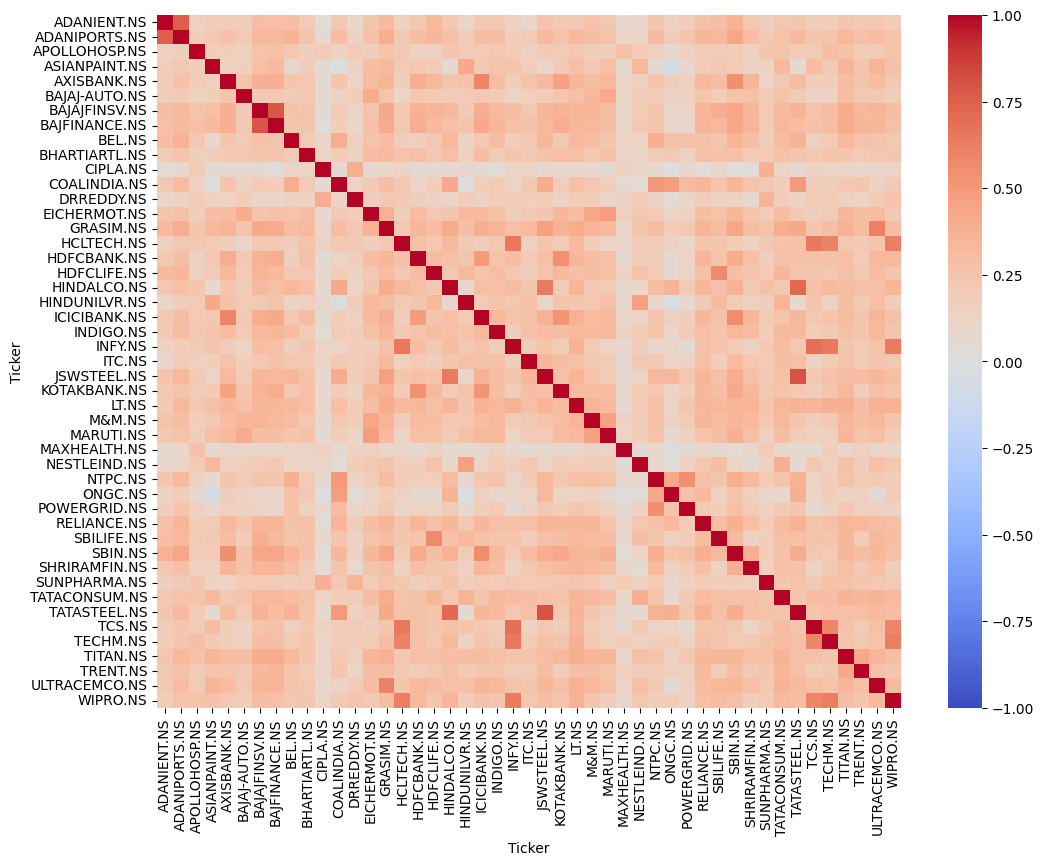

In [62]:
corr_matrix = log_returns.corr()

plt.figure(figsize=(12,9))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [63]:
scaled_log_returns = StandardScaler().fit_transform(log_returns)

pca = PCA(n_components=10)
pca.fit(scaled_log_returns)

PCA(n_components=10)

In [64]:
display(pca.explained_variance_)
display(pca.explained_variance_ratio_)

array([12.68513717,  2.80823044,  2.54384401,  1.82187765,  1.47994321,
        1.37731797,  1.35370275,  1.20126971,  1.15113191,  1.07603964])

array([0.26953181, 0.05966884, 0.0540512 , 0.03871097, 0.0314456 ,
       0.02926504, 0.02876326, 0.02552439, 0.02445907, 0.02286352])

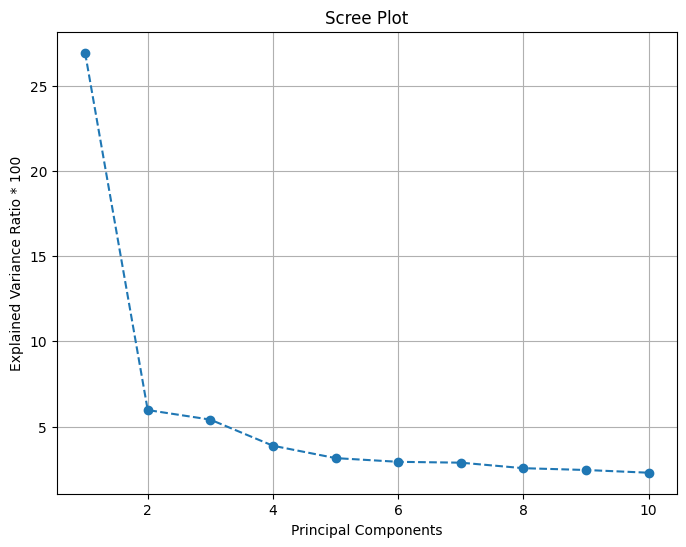

In [65]:
plt.figure(figsize=(8, 6))
plt.plot(range(1,11), pca.explained_variance_ratio_*100, marker='o', linestyle='--')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio * 100')
plt.title('Scree Plot')
plt.grid()
plt.show()

In [66]:
industry_map = (
    nifty50_df[['Symbol', 'Sector[15]']].drop_duplicates('Symbol').set_index('Symbol')['Sector[15]']
)

In [67]:
pc1_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[0] * 100
})

pc1_df['Industry'] = pc1_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc1_sorted = pc1_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc1_sorted.head(10))
display(pc1_sorted.tail(10))

,Ticker,Weight,Industry
14,GRASIM.NS,18.806001,Construction Materials
36,SBIN.NS,18.375968,Financial Services
6,BAJAJFINSV.NS,17.728589,Financial Services
26,LT.NS,17.719050,Construction
7,BAJFINANCE.NS,17.631608,Financial Services
24,JSWSTEEL.NS,17.158186,Metals & Mining
20,ICICIBANK.NS,17.004370,Financial Services
40,TATASTEEL.NS,16.993847,Metals & Mining
43,TITAN.NS,16.898615,Consumer Durables
34,RELIANCE.NS,16.628202,"Oil, Gas & Consumable Fuels"


,Ticker,Weight,Industry
19,HINDUNILVR.NS,12.080230,Fast Moving Consumer Goods
3,ASIANPAINT.NS,11.936861,Consumer Durables
38,SUNPHARMA.NS,11.840979,Healthcare
2,APOLLOHOSP.NS,11.505415,Healthcare
30,NESTLEIND.NS,10.488383,Fast Moving Consumer Goods
33,POWERGRID.NS,10.216436,Power
12,DRREDDY.NS,9.283003,Healthcare
32,ONGC.NS,9.156640,"Oil, Gas & Consumable Fuels"
29,MAXHEALTH.NS,5.814440,Healthcare
10,CIPLA.NS,5.172681,Healthcare


In [68]:
pc2_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[1] * 100
})

pc2_df['Industry'] = pc2_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc2_sorted = pc2_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc2_sorted.head(10))
display(pc2_sorted.tail(10))

,Ticker,Weight,Industry
22,INFY.NS,34.044887,Information Technology
41,TCS.NS,33.525506,Information Technology
15,HCLTECH.NS,30.098032,Information Technology
42,TECHM.NS,27.774470,Information Technology
46,WIPRO.NS,26.979067,Information Technology
3,ASIANPAINT.NS,19.262568,Consumer Durables
19,HINDUNILVR.NS,16.896755,Fast Moving Consumer Goods
30,NESTLEIND.NS,16.836016,Fast Moving Consumer Goods
12,DRREDDY.NS,12.406534,Healthcare
10,CIPLA.NS,11.702134,Healthcare


,Ticker,Weight,Industry
18,HINDALCO.NS,-11.132396,Metals & Mining
37,SHRIRAMFIN.NS,-13.507123,Financial Services
8,BEL.NS,-14.719915,Capital Goods
24,JSWSTEEL.NS,-15.941830,Metals & Mining
36,SBIN.NS,-17.028338,Financial Services
33,POWERGRID.NS,-17.210211,Power
40,TATASTEEL.NS,-18.285642,Metals & Mining
32,ONGC.NS,-21.675999,"Oil, Gas & Consumable Fuels"
11,COALINDIA.NS,-22.934991,"Oil, Gas & Consumable Fuels"
31,NTPC.NS,-23.299936,Power


In [69]:
pc3_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[2] * 100
})

pc3_df['Industry'] = pc3_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc3_sorted = pc3_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc3_sorted.head(10))
display(pc3_sorted.tail(10))

,Ticker,Weight,Industry
32,ONGC.NS,28.308528,"Oil, Gas & Consumable Fuels"
40,TATASTEEL.NS,26.562412,Metals & Mining
18,HINDALCO.NS,26.534309,Metals & Mining
11,COALINDIA.NS,25.468273,"Oil, Gas & Consumable Fuels"
15,HCLTECH.NS,24.795771,Information Technology
42,TECHM.NS,22.619689,Information Technology
46,WIPRO.NS,20.715398,Information Technology
22,INFY.NS,20.629075,Information Technology
24,JSWSTEEL.NS,20.325405,Metals & Mining
41,TCS.NS,18.897651,Information Technology


,Ticker,Weight,Industry
4,AXISBANK.NS,-12.358125,Financial Services
27,M&M.NS,-12.923677,Automobile and Auto Components
7,BAJFINANCE.NS,-13.178198,Financial Services
5,BAJAJ-AUTO.NS,-13.515608,Automobile and Auto Components
25,KOTAKBANK.NS,-15.155801,Financial Services
30,NESTLEIND.NS,-16.920269,Fast Moving Consumer Goods
13,EICHERMOT.NS,-17.792383,Automobile and Auto Components
3,ASIANPAINT.NS,-21.667984,Consumer Durables
28,MARUTI.NS,-21.738098,Automobile and Auto Components
19,HINDUNILVR.NS,-24.177199,Fast Moving Consumer Goods


In [70]:
pc4_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[3] * 100
})

pc4_df['Industry'] = pc4_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc4_sorted = pc4_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc4_sorted.head(10))
display(pc4_sorted.tail(10))

,Ticker,Weight,Industry
10,CIPLA.NS,40.188287,Healthcare
12,DRREDDY.NS,33.570898,Healthcare
38,SUNPHARMA.NS,32.397066,Healthcare
29,MAXHEALTH.NS,23.128273,Healthcare
33,POWERGRID.NS,19.982597,Power
2,APOLLOHOSP.NS,18.031119,Healthcare
30,NESTLEIND.NS,17.290481,Fast Moving Consumer Goods
31,NTPC.NS,14.654932,Power
5,BAJAJ-AUTO.NS,14.060900,Automobile and Auto Components
8,BEL.NS,13.562264,Capital Goods


,Ticker,Weight,Industry
46,WIPRO.NS,-9.609176,Information Technology
41,TCS.NS,-11.007155,Information Technology
25,KOTAKBANK.NS,-14.538562,Financial Services
22,INFY.NS,-15.062748,Information Technology
36,SBIN.NS,-15.316143,Financial Services
4,AXISBANK.NS,-17.872792,Financial Services
6,BAJAJFINSV.NS,-19.162481,Financial Services
7,BAJFINANCE.NS,-20.081593,Financial Services
16,HDFCBANK.NS,-22.261116,Financial Services
20,ICICIBANK.NS,-22.777293,Financial Services


### Performance Measurement

In [71]:
# ==============================================================================
# 1. CORE MATH & PORTFOLIO SIMULATION ENGINES
# ==============================================================================
def extract_strategy_weights(pca_model, columns, pc_index, strategy_type='auto'):
    """Extracts and normalizes weights based on the chosen strategy."""
    raw_weights = pca_model.components_[pc_index]
    
    # Auto-detect strategy: PC1 is usually Long-Only, everything else is Long/Short
    if strategy_type == 'auto':
        strategy_type = 'long_only' if pc_index == 0 else 'long_short'
        
    if strategy_type == 'long_only':
        # Fix sign direction for PC1
        if np.sum(raw_weights) < 0:
            raw_weights = -raw_weights
        long_weights = np.maximum(0, raw_weights)
        return pd.Series(long_weights / np.sum(long_weights), index=columns), 'Long-Only'
        
    elif strategy_type == 'long_short':
        # Normalize Longs to +1.0 and Shorts to -1.0 (Dollar Neutral)
        longs = np.maximum(0, raw_weights)
        shorts = np.minimum(0, raw_weights)
        norm_longs = longs / np.sum(longs) if np.sum(longs) > 0 else longs
        norm_shorts = shorts / abs(np.sum(shorts)) if np.sum(shorts) < 0 else shorts
        return pd.Series(norm_longs + norm_shorts, index=columns), 'Long/Short (Market Neutral)'

def simulate_portfolio(price_data, weights, initial_capital, strategy_name):
    """Simulates the portfolio equity curve based on strategy type."""
    initial_prices = price_data.iloc[0]
    shares = (initial_capital * weights) / initial_prices
    
    if strategy_name == 'Long-Only':
        # Portfolio value is just the current value of the shares held
        return price_data.dot(shares)
    else:
        # Long/Short Portfolio: Initial Capital is margin. 
        # PnL = (Current Prices * Shares). Note: Shorts are negative shares, so dropping prices = profit.
        return initial_capital + price_data.dot(shares)

def align_benchmark(benchmark_data, initial_capital):
    """Normalizes the benchmark to start at the exact same capital as the portfolio."""
    if isinstance(benchmark_data, pd.DataFrame):
        benchmark_data = benchmark_data.iloc[:, 0]
    return (benchmark_data / benchmark_data.iloc[0]) * initial_capital

# ==============================================================================
# 2. INSTITUTIONAL METRICS ENGINE
# ==============================================================================
def calculate_metrics(port_val, bench_val, rf_rate, periods_per_yr):
    df = pd.concat([port_val, bench_val], axis=1).dropna()
    df.columns = ['Portfolio', 'Benchmark']
    
    returns = df.pct_change().dropna()
    p_ret, b_ret = returns['Portfolio'], returns['Benchmark']
    
    # CAGR
    ann_p_ret = (df['Portfolio'].iloc[-1] / df['Portfolio'].iloc[0]) ** (periods_per_yr / len(returns)) - 1
    ann_b_ret = (df['Benchmark'].iloc[-1] / df['Benchmark'].iloc[0]) ** (periods_per_yr / len(returns)) - 1
    
    # Volatility
    ann_p_vol = p_ret.std() * np.sqrt(periods_per_yr)
    ann_b_vol = b_ret.std() * np.sqrt(periods_per_yr)
    
    # Sharpe
    p_sharpe = (ann_p_ret - rf_rate) / ann_p_vol
    b_sharpe = (ann_b_ret - rf_rate) / ann_b_vol
    
    # Sortino
    p_down_dev = np.sqrt(np.mean(np.where(p_ret < 0, p_ret**2, 0))) * np.sqrt(periods_per_yr)
    p_sortino = (ann_p_ret - rf_rate) / p_down_dev if p_down_dev > 0 else np.nan
    b_down_dev = np.sqrt(np.mean(np.where(b_ret < 0, b_ret**2, 0))) * np.sqrt(periods_per_yr)
    b_sortino = (ann_b_ret - rf_rate) / b_down_dev if b_down_dev > 0 else np.nan
    
    # Drawdowns
    p_dd = (df['Portfolio'] - df['Portfolio'].cummax()) / df['Portfolio'].cummax()
    b_dd = (df['Benchmark'] - df['Benchmark'].cummax()) / df['Benchmark'].cummax()
    
    # Beta & Alpha
    cov = np.cov(p_ret, b_ret)
    beta = cov[0, 1] / cov[1, 1]
    alpha = ann_p_ret - (rf_rate + beta * (ann_b_ret - rf_rate))
    
    # Calmar
    p_calmar = ann_p_ret / abs(p_dd.min())
    b_calmar = ann_b_ret / abs(b_dd.min())
    
    metrics = pd.DataFrame({
        'Portfolio': [f"{ann_p_ret*100:.2f}%", f"{ann_p_vol*100:.2f}%", f"{p_sharpe:.2f}", f"{p_sortino:.2f}", f"{p_dd.min()*100:.2f}%", f"{p_calmar:.2f}", f"{beta:.2f}", f"{alpha*100:.2f}%"],
        'Benchmark': [f"{ann_b_ret*100:.2f}%", f"{ann_b_vol*100:.2f}%", f"{b_sharpe:.2f}", f"{b_sortino:.2f}", f"{b_dd.min()*100:.2f}%", f"{b_calmar:.2f}", "1.00", "0.00%"]
    }, index=['Return (CAGR)', 'Volatility', 'Sharpe Ratio', 'Sortino Ratio', 'Max Drawdown', 'Calmar Ratio', 'Beta', "Jensen's Alpha"])
    
    return metrics, p_dd, b_dd, p_ret, b_ret

# ==============================================================================
# 3. MASTER WRAPPER & PLOTTING DASHBOARD
# ==============================================================================
def evaluate_pc_strategy(pca_model, pc_index, price_data, benchmark_data, strategy='auto', initial_capital=100000, rf_rate=0.06, periods_per_yr=52):
    """
    The Ultimate Master Function. Put in a PC index, get out the full institutional dashboard.
    """
    # 1. Build Portfolio
    weights, strat_name = extract_strategy_weights(pca_model, price_data.columns, pc_index, strategy)
    port_val = simulate_portfolio(price_data, weights, initial_capital, strat_name)
    bench_val = align_benchmark(benchmark_data, initial_capital)
    
    # 2. Get Metrics
    metrics_df, p_dd, b_dd, p_ret, b_ret = calculate_metrics(port_val, bench_val, rf_rate, periods_per_yr)
    
    # 3. Print Results
    actual_pc = pc_index + 1
    print("\n" + "="*65)
    print(f" STRATEGY REPORT: Principal Component {actual_pc} [{strat_name}]")
    print("="*65)
    display(metrics_df)
    
    # 4. Render Dashboard
    fig = plt.figure(figsize=(14, 12))
    gs = fig.add_gridspec(3, 1, height_ratios=[2.5, 1, 1], hspace=0.3)
    
    # Chart 1: Equity Curve
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(port_val.index, (port_val/initial_capital)*100, label=f'PC{actual_pc} Portfolio', color='#1f77b4', linewidth=2.5)
    ax1.plot(bench_val.index, (bench_val/initial_capital)*100, label='Benchmark', color='#4a4a4a', linewidth=1.5, alpha=0.8)
    ax1.set_title(f'Equity Curve (Normalized to 100 Base)', fontsize=14, fontweight='bold', loc='left')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper left')
    
    # Chart 2: Drawdowns
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.fill_between(p_dd.index, p_dd * 100, 0, color='#d62728', alpha=0.3, label='Portfolio Drawdown')
    ax2.plot(b_dd.index, b_dd * 100, color='black', linewidth=1.2, alpha=0.7, label='Benchmark Drawdown')
    ax2.set_title('Underwater Plot (Capital Drawdowns %)', fontsize=12, fontweight='bold', loc='left')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='lower right')
    
    # Chart 3: Rolling Beta
    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    rolling_window = max(int(periods_per_yr / 2), 1) # 6-month rolling window
    rolling_beta = p_ret.rolling(window=rolling_window).cov(b_ret) / b_ret.rolling(window=rolling_window).var()
    ax3.plot(rolling_beta.index, rolling_beta, color='#2ca02c', linewidth=2, label=f'Rolling {rolling_window}-Period Beta')
    ax3.axhline(1.0 if strat_name == 'Long-Only' else 0.0, color='black', linestyle='--', alpha=0.5, label='Target Beta')
    ax3.set_title(f'Systemic Risk (Rolling {rolling_window}-Period Beta)', fontsize=12, fontweight='bold', loc='left')
    ax3.grid(True, linestyle='--', alpha=0.5)
    ax3.legend(loc='lower left')
    
    plt.show()




 STRATEGY REPORT: Principal Component 1 [Long-Only]


,Portfolio,Benchmark
Return (CAGR),8.55%,2.82%
Volatility,15.06%,14.02%
Sharpe Ratio,0.17,-0.23
Sortino Ratio,0.24,-0.32
Max Drawdown,-15.95%,-15.77%
Calmar Ratio,0.54,0.18
Beta,1.04,1.00
Jensen's Alpha,5.86%,0.00%


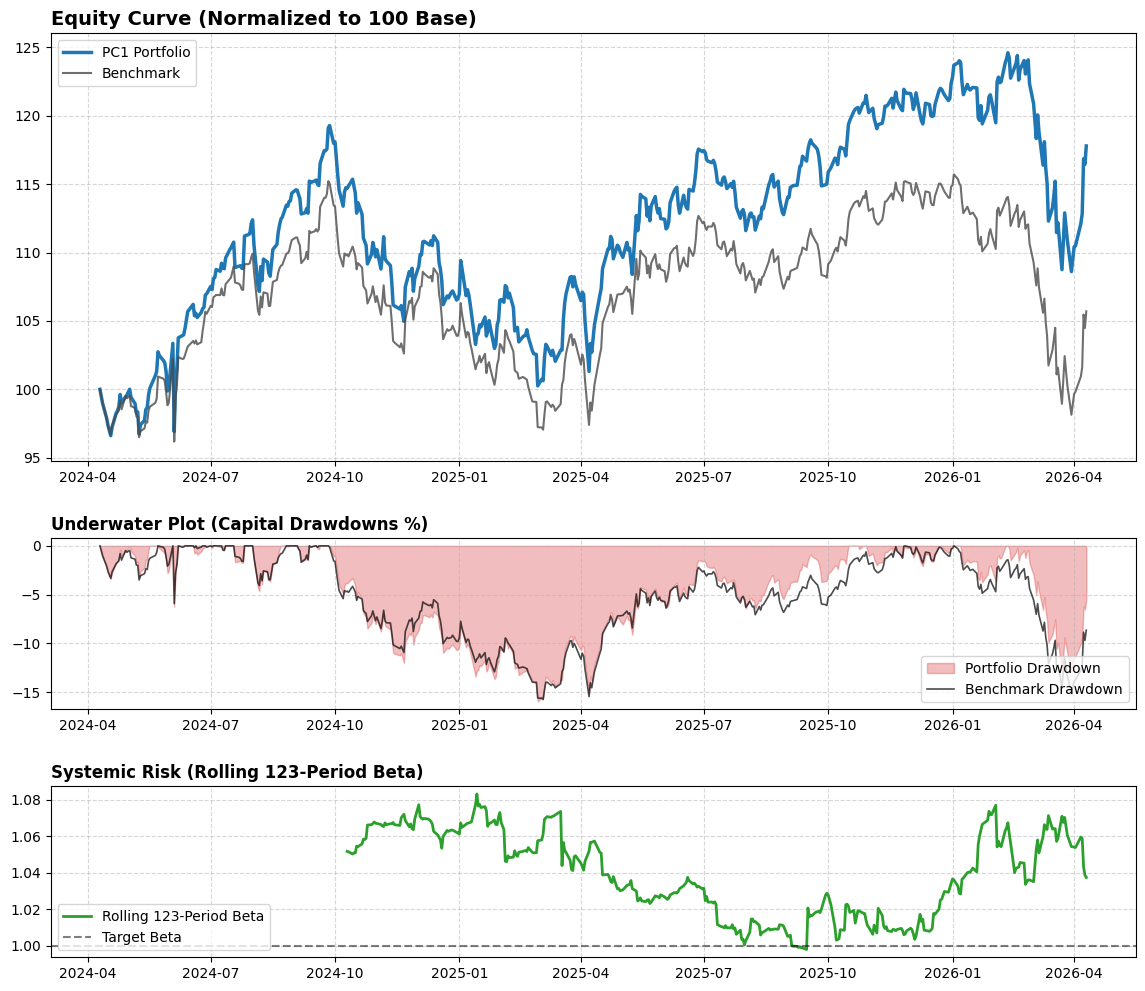

In [72]:
# Test PC1
evaluate_pc_strategy(pca_model=pca, pc_index=0, price_data=X_test, benchmark_data=y_test, periods_per_yr=247)


 STRATEGY REPORT: Principal Component 2 [Long/Short (Market Neutral)]


,Portfolio,Benchmark
Return (CAGR),-18.08%,2.82%
Volatility,22.17%,14.02%
Sharpe Ratio,-1.09,-0.23
Sortino Ratio,-1.63,-0.32
Max Drawdown,-45.65%,-15.77%
Calmar Ratio,-0.40,0.18
Beta,-0.69,1.00
Jensen's Alpha,-26.29%,0.00%


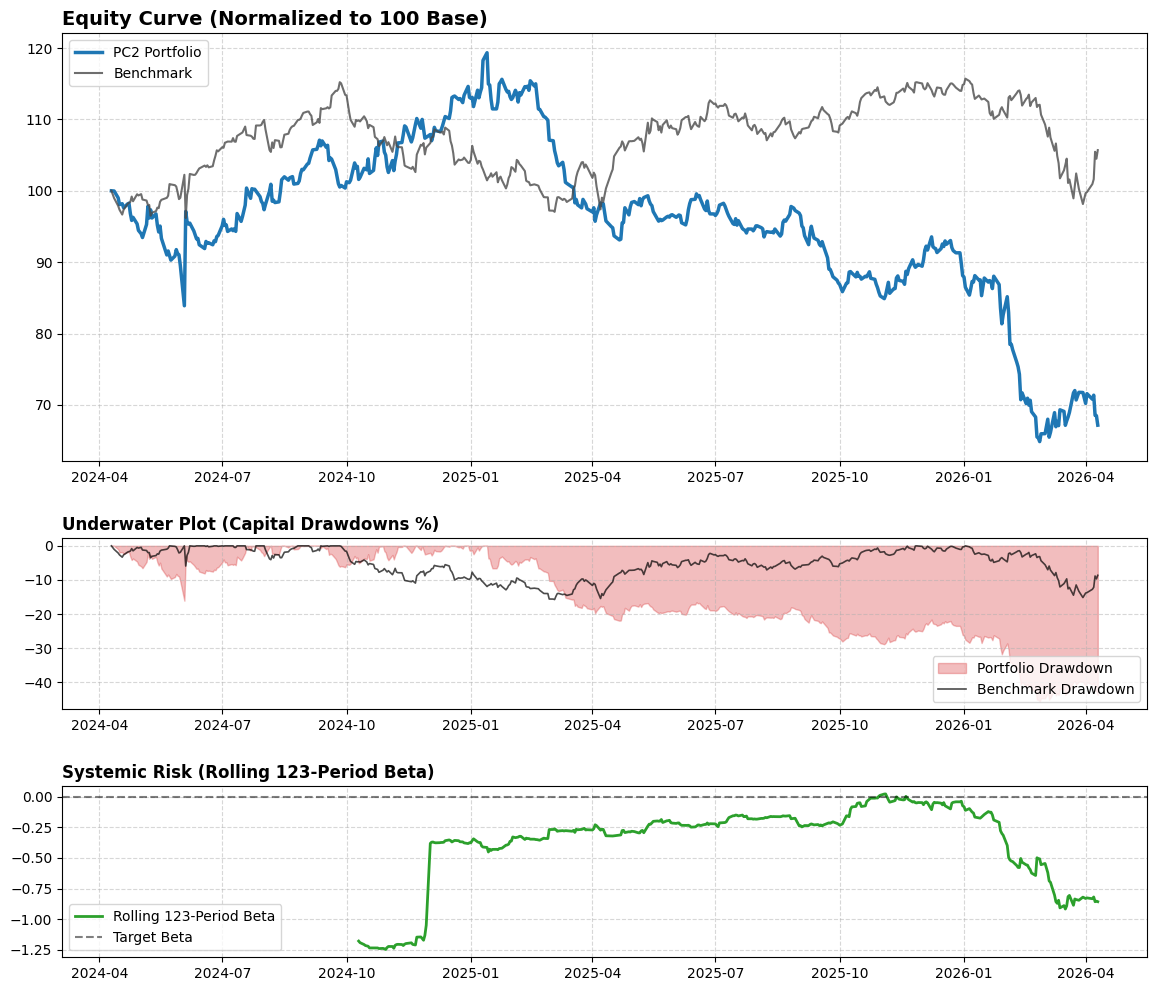

In [73]:
# Test PC2
evaluate_pc_strategy(pca_model=pca, pc_index=1, price_data=X_test, benchmark_data=y_test, periods_per_yr=247)


 STRATEGY REPORT: Principal Component 3 [Long/Short (Market Neutral)]


,Portfolio,Benchmark
Return (CAGR),-0.52%,2.82%
Volatility,15.93%,14.02%
Sharpe Ratio,-0.41,-0.23
Sortino Ratio,-0.55,-0.32
Max Drawdown,-23.02%,-15.77%
Calmar Ratio,-0.02,0.18
Beta,0.01,1.00
Jensen's Alpha,-6.48%,0.00%


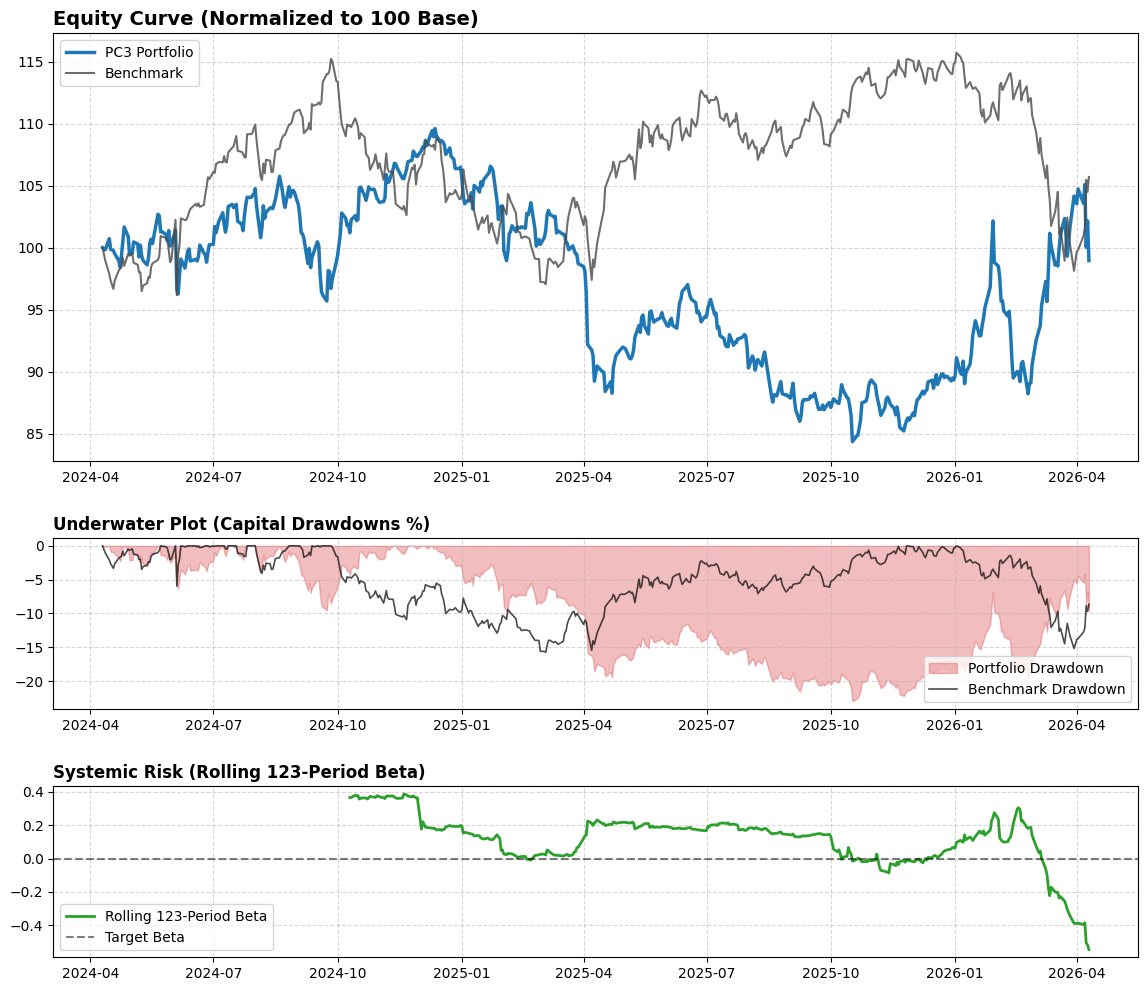

In [74]:
# Test PC3
evaluate_pc_strategy(pca_model=pca, pc_index=2, price_data=X_test, benchmark_data=y_test, periods_per_yr=247)


 STRATEGY REPORT: Principal Component 4 [Long/Short (Market Neutral)]


,Portfolio,Benchmark
Return (CAGR),-2.46%,2.82%
Volatility,13.20%,14.02%
Sharpe Ratio,-0.64,-0.23
Sortino Ratio,-0.92,-0.32
Max Drawdown,-22.57%,-15.77%
Calmar Ratio,-0.11,0.18
Beta,-0.32,1.00
Jensen's Alpha,-9.47%,0.00%


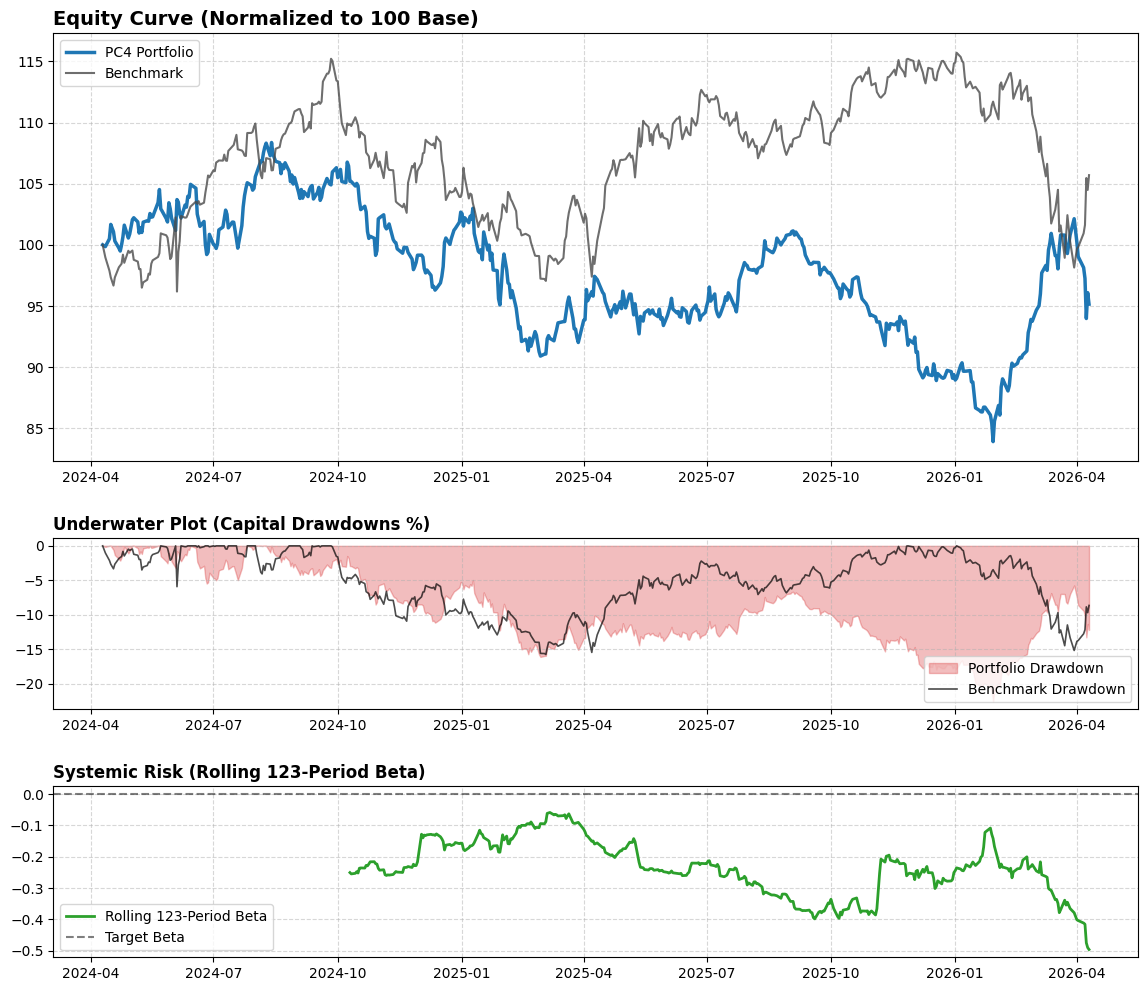

In [75]:
evaluate_pc_strategy(pca_model=pca, pc_index=3, price_data=X_test, benchmark_data=y_test, periods_per_yr=247)